In [1]:
import socket
print(socket.gethostname())

awr-2-24


In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from dask.distributed import Client
client = Client(n_workers=8, threads_per_worker=4)

print(client.dashboard_link)
print(client)

http://127.0.0.1:8787/status
<Client: 'tcp://127.0.0.1:41397' processes=8 threads=32, memory=64.00 GiB>


### Pressure & Temperature

* **Mean sea level pressure (slp):** `mean_sea_level_pressure`
* **Surface pressure (p_sfc):** `surface_pressure`
* **2-m dewpoint temperature (Td_2m):** `2m_dewpoint_temperature`
* **2-m temperature (T_2m):** `2m_temperature`
* **Skin temperature (T_sfc):** `skin_temperature`
* **Sea surface temperature:** `sea_surface_temperature` *(Note: In ERA5, Skin Temperature is often used over land/ice, while SST is used over open ocean).*

### Moisture & Transport

* **Integrated water vapor (IWV):** `total_column_water_vapour`
* **Integrated vapor transport (meridional) (IVTV):** `vertical_integral_of_northward_water_vapour_flux`
* **Integrated vapor transport (zonal) (IVTU):** `vertical_integral_of_eastward_water_vapour_flux`

### Wind & Precipitation

* **10-m zonal wind (u_10m_gr):** `10m_u_component_of_wind`
* **10-m meridional wind (v_10m_gr):** `10m_v_component_of_wind`
* **6-hourly accumulated precipitation (precip_bkt):** `total_precipitation`

### Forcing
* **Geopotential at the surface (Z_sfc):** `geopotential_at_surface`

---

### Summary Table for Quick Reference

| WRF Variable | ERA5 Equivalent Name |
| --- | --- |
| **msl** | `mean_sea_level_pressure` |
| **sp** | `surface_pressure` |
| **d2m** | `2m_dewpoint_temperature` |
| **2t** | `2m_temperature` |
| **t_sfc** | `skin_temperature` / `sea_surface_temperature` |
| **iwv** | `total_column_water_vapour` |
| **ivt_u / ivt_v** | `vertical_integral_of_eastward/northward_water_vapour_flux` |
| **10u / 10v** | `10m_u_component_of_wind` / `10m_v_component_of_wind` |
| **tp** | `total_precipitation` |
| **z_sfc** |  `geopotential_at_surface` |
| **lsm** |  ` land_sea_mask` |
| **tisr** |  ` toa_incident_solar_radiation` |

### Pressure-Level Variables (3D)

| WRF Variable | ERA5 Equivalent Name | Dimensions |
| --- | --- | --- |
| **Geopotential (z)** | `geopotential` | (time, level, latitude, longitude) |
| **Temperature (t)** | `temperature` | (time, level, latitude, longitude) |
| **Specific humidity (q)** | `specific_humidity` | (time, level, latitude, longitude) |
| **Zonal wind (u)** | `u_component_of_wind` | (time, level, latitude, longitude) |
| **Meridional wind (v)** | `v_component_of_wind` | (time, level, latitude, longitude) |



In [13]:
ds = xr.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/model-level-1h-0p25deg.zarr-v1',
    chunks={},
    storage_options=dict(token='anon'),
)
ar_native_vertical_grid_data = ds.sel(time=slice('2019-01-01T00:00:00.000000000', '2019-01-01T03:00:00.000000000'))

In [14]:
ds = xr.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3',
    chunks={},
    storage_options=dict(token='anon'),
)
ar_full_37_1h = ds.sel(time=slice('2019-01-01T00:00:00.000000000', '2019-01-01T03:00:00.000000000'))

ar_model_level_and_surface_data = xr.merge([
    ar_native_vertical_grid_data, ar_full_37_1h.drop_dims('level')
])

In [15]:
# 1. Load variable configuration from JSON
import json

with open('variable_config.json', 'r') as f:
    config = json.load(f)

selected_vars = []
rename_map = {}

for short, info in config['surface_variables'].items():
    if 'era5_name' in info:
        selected_vars.append(info['era5_name'])
        rename_map[info['era5_name']] = short
    elif 'era5_names' in info:
        selected_vars.extend(info['era5_names'])

for short, info in config['pressure_variables'].items():
    selected_vars.append(info['era5_name'])
    rename_map[info['era5_name']] = short

# Apply selection and renaming
ds_combined = ar_model_level_and_surface_data[selected_vars].rename(rename_map)

# # Handle t_sfc as sum of skin_temperature and sea_surface_temperature
# ds_combined['t_sfc'] = ds_combined['skin_temperature'] + ds_combined['sea_surface_temperature']
# ds_combined = ds_combined.drop_vars(['skin_temperature', 'sea_surface_temperature'])

# Set attributes
for short, info in config['surface_variables'].items():
    if short in ds_combined.data_vars:
        ds_combined[short].attrs.update(info['attributes'])

for short, info in config['pressure_variables'].items():
    if short in ds_combined.data_vars:
        ds_combined[short].attrs.update(info['attributes'])

In [16]:
ds_combined

<xarray.Dataset> Size: 12GB
Dimensions:    (time: 4, latitude: 721, longitude: 1440, hybrid: 137)
Coordinates:
  * time       (time) datetime64[ns] 32B 2019-01-01 ... 2019-01-01T03:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * hybrid     (hybrid) float32 548B 1.0 2.0 3.0 4.0 ... 134.0 135.0 136.0 137.0
Data variables: (12/19)
    msl        (time, latitude, longitude) float32 17MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    sp         (time, latitude, longitude) float32 17MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    d2m        (time, latitude, longitude) float32 17MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    2t         (time, latitude, longitude) float32 17MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    t_sfc      (time, latitude, longitude) float32 17MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    iwv        (time, latitude, longitude) float32 17MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    ...         ...
    tisr       (time, latitude, longitude) float32 17MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    z          (time, hybrid, latitude, longitude) float32 2GB dask.array<chunksize=(1, 18, 721, 1440), meta=np.ndarray>
    t          (time, hybrid, latitude, longitude) float32 2GB dask.array<chunksize=(1, 18, 721, 1440), meta=np.ndarray>
    q          (time, hybrid, latitude, longitude) float32 2GB dask.array<chunksize=(1, 18, 721, 1440), meta=np.ndarray>
    u          (time, hybrid, latitude, longitude) float32 2GB dask.array<chunksize=(1, 18, 721, 1440), meta=np.ndarray>
    v          (time, hybrid, latitude, longitude) float32 2GB dask.array<chunksize=(1, 18, 721, 1440), meta=np.ndarray>
Attributes:
    last_updated:      2026-03-18 07:47:33.081855+00:00
    valid_time_start:  1940-01-01
    valid_time_stop:   2025-12-31

In [17]:
lats_n320=np.load("N320-coords/lats_n320.npy")
lons_n320=np.load("N320-coords/lons_n320.npy")

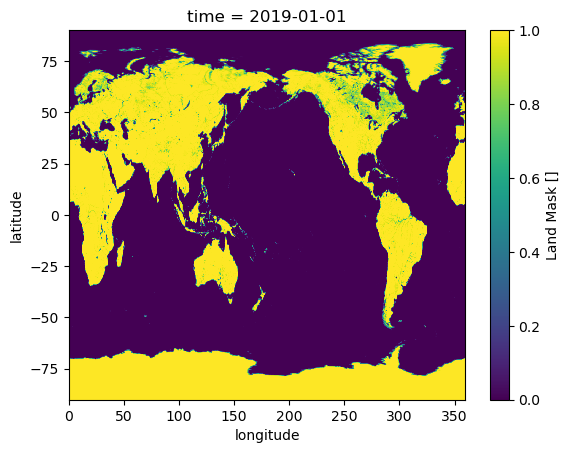

In [14]:
ds_combined.lsm.isel(time=0).plot()

In [25]:
import xesmf as xe
import xarray as xr

# 1. Define your target grid as a dictionary
ds_out = {
    'lon': lons_n320,
    'lat': lats_n320
}

# Rename coordinates upfront so we don't have to repeat it
ds_renamed = ds_combined.rename({'longitude': 'lon', 'latitude': 'lat'})

# 2. Split the dataset based on interpolation needs
ds_lsm = ds_renamed[['lsm']]               # Only the mask
ds_continuous = ds_renamed.drop_vars('lsm') # Everything EXCEPT the mask

# 3. Build both regridders ONCE
print("Building bilinear regridder for continuous variables...")
regridder_bilinear = xe.Regridder(
    ds_continuous, 
    ds_out, 
    method='bilinear', 
    locstream_out=True
)

print("Building nearest-neighbor regridder for categorical mask...")
regridder_nearest = xe.Regridder(
    ds_lsm, 
    ds_out, 
    method='nearest_s2d', 
    locstream_out=True
)

# 4. Apply the regridders to their respective datasets
# Because the chunks are preserved, this builds the Dask graph instantly
print("Applying interpolation...")
interpolated_continuous = regridder_bilinear(ds_continuous)
interpolated_lsm = regridder_nearest(ds_lsm)

# 5. Merge them back together into your final dataset
interpolated_data = xr.merge([interpolated_continuous, interpolated_lsm])

# Optional but recommended: xESMF sometimes drops global dataset attributes during merging.
# This copies the original global attributes to your new dataset.
interpolated_data.attrs = ds_combined.attrs

print("Done! Dataset is ready.")

Building bilinear regridder for continuous variables...
Building nearest-neighbor regridder for categorical mask...
Applying interpolation...
Done! Dataset is ready.


In [26]:
interpolated_data


<xarray.Dataset> Size: 6GB
Dimensions:  (time: 4, locations: 542080, hybrid: 137)
Coordinates:
  * time     (time) datetime64[ns] 32B 2019-01-01 ... 2019-01-01T03:00:00
    lat      (locations) float64 4MB 89.78 89.78 89.78 ... -89.78 -89.78 -89.78
    lon      (locations) float64 4MB 0.0 20.0 40.0 60.0 ... 300.0 320.0 340.0
  * hybrid   (hybrid) float32 548B 1.0 2.0 3.0 4.0 ... 134.0 135.0 136.0 137.0
Dimensions without coordinates: locations
Data variables: (12/19)
    msl      (time, locations) float32 9MB dask.array<chunksize=(1, 542080), meta=np.ndarray>
    sp       (time, locations) float32 9MB dask.array<chunksize=(1, 542080), meta=np.ndarray>
    d2m      (time, locations) float32 9MB dask.array<chunksize=(1, 542080), meta=np.ndarray>
    2t       (time, locations) float32 9MB dask.array<chunksize=(1, 542080), meta=np.ndarray>
    t_sfc    (time, locations) float32 9MB dask.array<chunksize=(1, 542080), meta=np.ndarray>
    iwv      (time, locations) float32 9MB dask.array<chunksize=(1, 542080), meta=np.ndarray>
    ...       ...
    z        (time, hybrid, locations) float32 1GB dask.array<chunksize=(1, 18, 542080), meta=np.ndarray>
    t        (time, hybrid, locations) float32 1GB dask.array<chunksize=(1, 18, 542080), meta=np.ndarray>
    q        (time, hybrid, locations) float32 1GB dask.array<chunksize=(1, 18, 542080), meta=np.ndarray>
    u        (time, hybrid, locations) float32 1GB dask.array<chunksize=(1, 18, 542080), meta=np.ndarray>
    v        (time, hybrid, locations) float32 1GB dask.array<chunksize=(1, 18, 542080), meta=np.ndarray>
    lsm      (time, locations) float32 9MB dask.array<chunksize=(1, 542080), meta=np.ndarray>
Attributes:
    last_updated:      2026-03-18 07:47:33.081855+00:00
    valid_time_start:  1940-01-01
    valid_time_stop:   2025-12-31